In [30]:
from google.colab import files
uploaded = files.upload()

Saving project_train_data.csv to project_train_data (1).csv


In [31]:
import pandas as pd

df = pd.read_csv('project_train_data.csv')

df.head()

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
1,2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
2,3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
3,4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
4,5,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0


In [32]:
df.shape
df.columns

Index(['Id', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [33]:
df.isnull().sum()

,0
Id,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,20781
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [34]:
# Replace missing values using median imputation (safe method)

df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

In [35]:
df.isnull().sum()

,0
Id,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [36]:
# Verify that missing values have been handled

df.isnull().sum()

,0
Id,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [37]:
# Check distribution of the target variable

df['SeriousDlqin2yrs'].value_counts()

,count
SeriousDlqin2yrs,
0,97855
1,6950


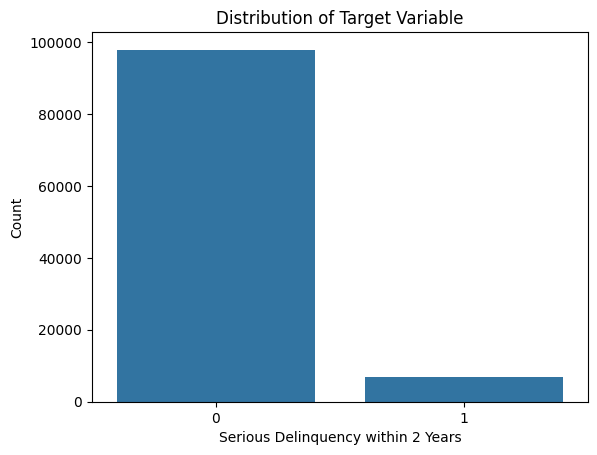

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title("Distribution of Target Variable")
plt.xlabel("Serious Delinquency within 2 Years")
plt.ylabel("Count")
plt.show()

In [39]:
# The identifier column (Id) was removed because it does not contain predictive information. The remaining variables were separated into predictor variables (X) and the target variable (y). The dataset was then divided into training and testing subsets using an 80–20 split. Stratified sampling was applied to maintain the original distribution of the target variable in both subsets.

# Remove the identifier column

df = df.drop(columns=['Id'])

In [40]:
# Define features (X) and target variable (y)

X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

In [41]:
X.shape, y.shape

((104805, 10), (104805,))

In [42]:
# To evaluate the model properly, we split the dataset.

# 80% → Training

# 20% → Testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [43]:
X_train.shape, X_test.shape

((83844, 10), (20961, 10))

In [44]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression(max_iter=1000)

# Train model
log_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [47]:
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

accuracy, precision, recall, f1, auc

(0.9342588616955297,
 0.5625,
 0.03884892086330935,
 0.07267833109017496,
 np.float64(0.6881330804754796))

In [49]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [50]:
# Generate predictions using Random Forest

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [51]:
# Evaluate Random Forest performance

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

accuracy_rf, precision_rf, recall_rf, f1_rf, auc_rf

(0.9352130146462478,
 0.5361990950226244,
 0.17050359712230215,
 0.2587336244541485,
 np.float64(0.845579827589566))

In [53]:
# Logistic Regression results

results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC-AUC": [auc]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.934259,0.5625,0.038849,0.072678,0.688133


In [54]:
# Add Random Forest results

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy_rf],
    "Precision": [precision_rf],
    "Recall": [recall_rf],
    "F1 Score": [f1_rf],
    "ROC-AUC": [auc_rf]
})

results = pd.concat([results, rf_results], ignore_index=True)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.934259,0.562500,0.038849,0.072678,0.688133
1,Random Forest,0.935213,0.536199,0.170504,0.258734,0.845580


In [55]:
# Gradient Boosting Model

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [56]:
# Generate predictions using Gradient Boosting

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

In [57]:
# Evaluate Gradient Boosting performance

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

accuracy_gb, precision_gb, recall_gb, f1_gb, auc_gb

(0.9385048423262249,
 0.6145124716553289,
 0.1949640287769784,
 0.2960131075914801,
 np.float64(0.8660764771249783))

In [58]:
# Add Gradient Boosting results to comparison table

gb_results = pd.DataFrame({
    "Model": ["Gradient Boosting"],
    "Accuracy": [accuracy_gb],
    "Precision": [precision_gb],
    "Recall": [recall_gb],
    "F1 Score": [f1_gb],
    "ROC-AUC": [auc_gb]
})

results = pd.concat([results, gb_results], ignore_index=True)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.934259,0.562500,0.038849,0.072678,0.688133
1,Random Forest,0.935213,0.536199,0.170504,0.258734,0.845580
2,Gradient Boosting,0.938505,0.614512,0.194964,0.296013,0.866076


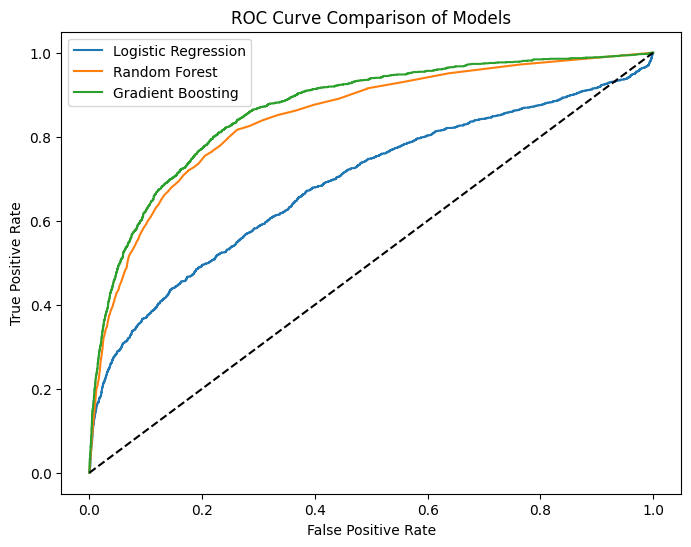

In [59]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.show()

In [61]:
# Explainable
!pip install shap

In [62]:
import shap

# initialize JS visualization
shap.initjs()

In [63]:
# Create SHAP explainer
explainer = shap.TreeExplainer(gb_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

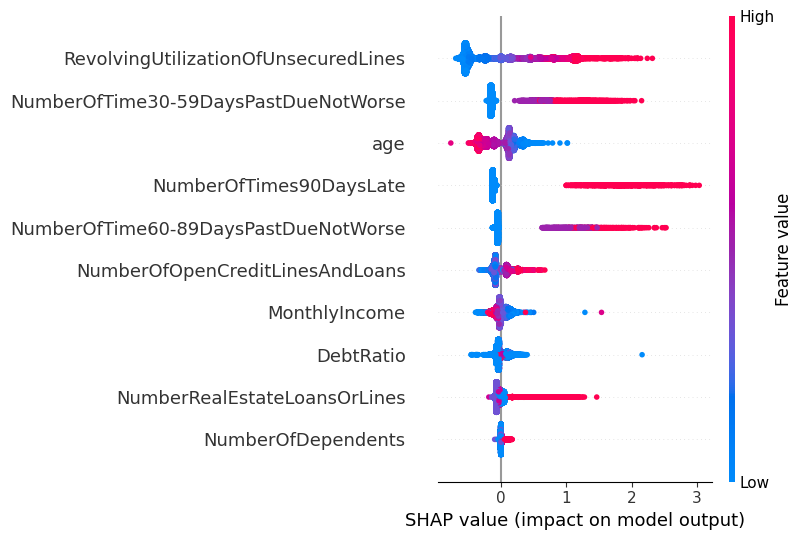

In [64]:
shap.summary_plot(shap_values, X_test)

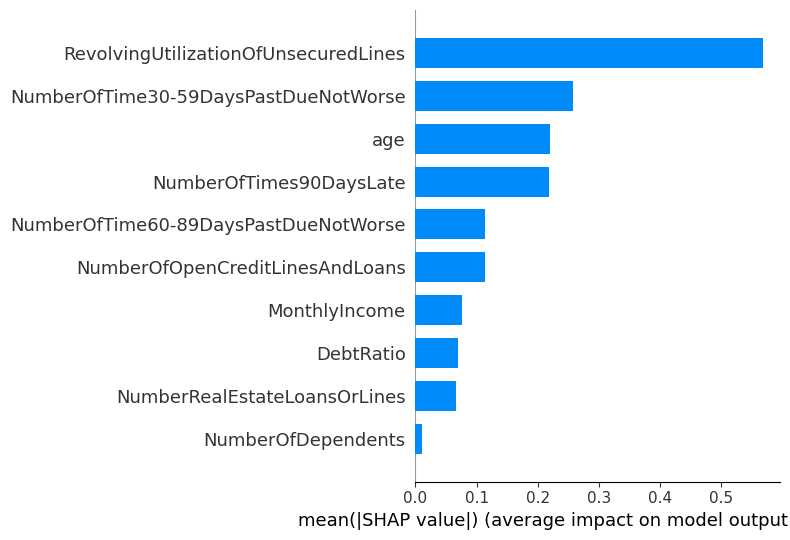

In [65]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

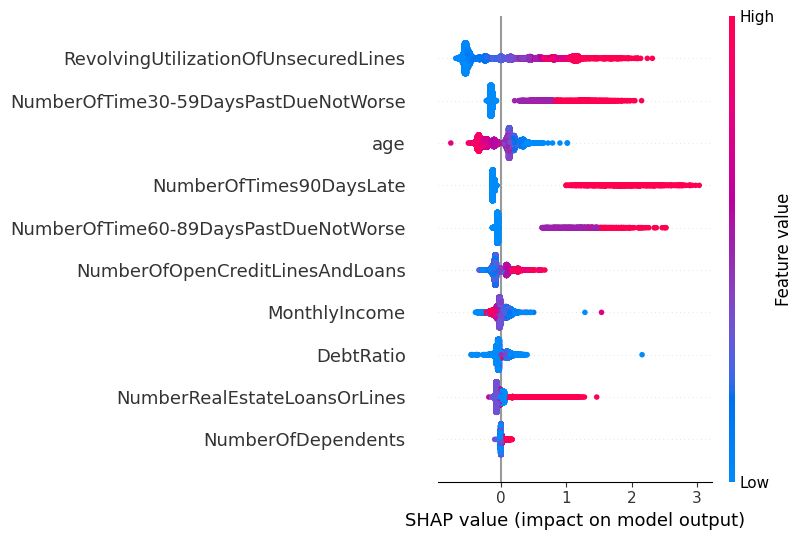

In [66]:
shap.summary_plot(shap_values, X_test)

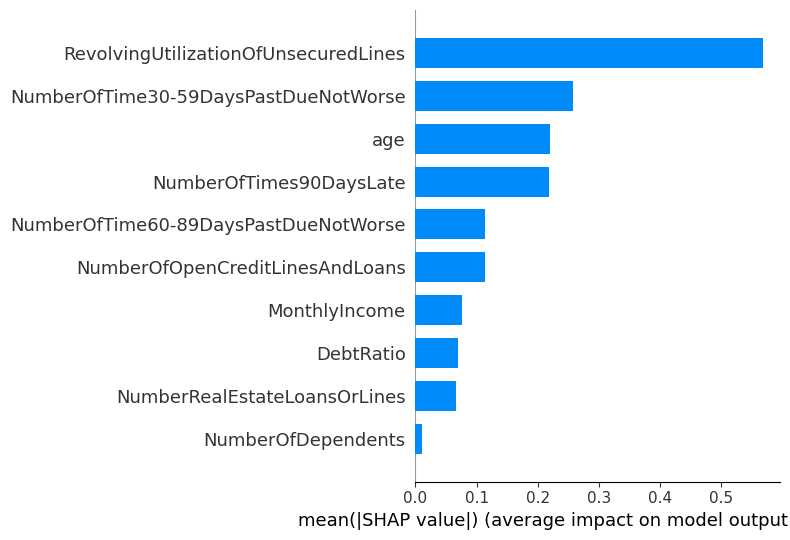

In [67]:
# SHAP Feature Importance Bar Plot

shap.summary_plot(shap_values, X_test, plot_type="bar")

In [68]:
import joblib

# Save trained Gradient Boosting model
joblib.dump(gb_model, "credit_risk_gradient_boosting_model.pkl")

['credit_risk_gradient_boosting_model.pkl']